# Retail Sales Analysis — 2014
## Objective
Analyze retail sales data across 100 locations and 105,916 products to identify revenue trends, 
top performers, and margin efficiency.

**Dataset:** 923,371 rows | 10 columns | Single year (2014)

In [1]:
import pandas as pd
df = pd.read_excel('Retail_Analysis_Project.xlsx')

In [2]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\ranji\PycharmProjects\pythonProject2
['.idea', '.ipynb_checkpoints', 'main.py', 'Retail_Analysis_Project.xlsx', 'Retail_Sales_Analysis.ipynb', 'venv']


## 1. Data Loading & Exploration
Loading the dataset and inspecting structure, data types, and null values.

In [3]:
print(df.info())
print("\n")
print(df.describe())
print("\n")
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 923371 entries, 0 to 923370
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   MonthID                     923371 non-null  int64  
 1   ItemID                      923371 non-null  int64  
 2   LocationID                  923371 non-null  int64  
 3   Sum_GrossMarginAmount       923371 non-null  float64
 4   Sum_Regular_Sales_Dollars   923371 non-null  float64
 5   Sum_Markdown_Sales_Dollars  923371 non-null  float64
 6   ScenarioID                  923371 non-null  int64  
 7   ReportingPeriodID           923371 non-null  int64  
 8   Sum_Regular_Sales_Units     923371 non-null  int64  
 9   Sum_Markdown_Sales_Units    923371 non-null  int64  
dtypes: float64(3), int64(7)
memory usage: 70.4 MB
None


             MonthID         ItemID     LocationID  Sum_GrossMarginAmount  \
count  923371.000000  923371.000000  923371.000000          923371.00

## 2. Feature Engineering
Converting MonthID to datetime format and creating derived columns:
- `Total_Sales_Dollars` = Regular + Markdown sales
- `Total_Sales_Units` = Regular + Markdown units

In [4]:
df['MonthID'] = pd.to_datetime(df['MonthID'], format='%Y%m')
df['Year'] = df['MonthID'].dt.year
df['Month'] = df['MonthID'].dt.month

In [5]:
df['Total_Sales_Dollars'] = df['Sum_Regular_Sales_Dollars'] + df['Sum_Markdown_Sales_Dollars']
df['Total_Sales_Units'] = df['Sum_Regular_Sales_Units'] + df['Sum_Markdown_Sales_Units']

In [6]:
monthly = df.groupby('MonthID')['Total_Sales_Dollars'].sum().reset_index()
print(monthly)

     MonthID  Total_Sales_Dollars
0 2014-01-01           3824377.85
1 2014-02-01           5165242.67
2 2014-03-01           6538112.51
3 2014-04-01           6043602.06
4 2014-05-01           5362013.21
5 2014-06-01           6021182.27
6 2014-07-01           5563895.63
7 2014-08-01           6666127.49


In [7]:
print(df.groupby('ScenarioID')['Total_Sales_Dollars'].sum())

ScenarioID
1    22051952.35
2    23132601.34
Name: Total_Sales_Dollars, dtype: float64


In [8]:
top_items = df.groupby('ItemID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(10)
print(top_items)

ItemID
17791     98697.63
319484    38754.60
245617    38221.96
186407    36986.52
226794    33526.44
186404    33486.25
217217    28850.28
206833    27245.45
220949    26292.64
177965    26223.79
Name: Total_Sales_Dollars, dtype: float64


In [9]:
top_locations = df.groupby('LocationID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(10)
print(top_locations)

LocationID
13    1370946.11
14    1193373.71
28    1178972.44
19    1098148.97
24    1083932.93
27    1037575.73
39    1013755.85
16    1009702.01
11    1005079.90
21     973333.22
Name: Total_Sales_Dollars, dtype: float64


In [10]:
margin_loc = df.groupby('LocationID')['Sum_GrossMarginAmount'].sum().sort_values(ascending=False)
print(margin_loc.head(10))
print(margin_loc.tail(10))  # loss-making locations

LocationID
13    597047.420
14    511584.190
28    495927.944
19    468948.343
24    457818.180
16    448067.050
27    429617.495
39    411906.349
11    411882.310
23    406861.024
Name: Sum_GrossMarginAmount, dtype: float64
LocationID
558    70441.30
524    69762.52
543    68672.52
575    62987.19
582    61779.83
566    57849.37
522    53358.25
583    51984.46
568    45260.11
565    18065.87
Name: Sum_GrossMarginAmount, dtype: float64


In [11]:
top_items = df.groupby('ItemID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(10)
print(top_items)

ItemID
17791     98697.63
319484    38754.60
245617    38221.96
186407    36986.52
226794    33526.44
186404    33486.25
217217    28850.28
206833    27245.45
220949    26292.64
177965    26223.79
Name: Total_Sales_Dollars, dtype: float64


In [12]:
top_locations = df.groupby('LocationID')['Total_Sales_Dollars'].sum().sort_values(ascending=False).head(10)
print(top_locations)

LocationID
13    1370946.11
14    1193373.71
28    1178972.44
19    1098148.97
24    1083932.93
27    1037575.73
39    1013755.85
16    1009702.01
11    1005079.90
21     973333.22
Name: Total_Sales_Dollars, dtype: float64


In [13]:
margin_loc = df.groupby('LocationID')['Sum_GrossMarginAmount'].sum().sort_values(ascending=False)
print(margin_loc.head(10))
print(margin_loc.tail(10))

LocationID
13    597047.420
14    511584.190
28    495927.944
19    468948.343
24    457818.180
16    448067.050
27    429617.495
39    411906.349
11    411882.310
23    406861.024
Name: Sum_GrossMarginAmount, dtype: float64
LocationID
558    70441.30
524    69762.52
543    68672.52
575    62987.19
582    61779.83
566    57849.37
522    53358.25
583    51984.46
568    45260.11
565    18065.87
Name: Sum_GrossMarginAmount, dtype: float64


## 3. Exploratory Data Analysis (EDA)
### 3.1 Monthly Sales Trend
Identifying seasonal patterns across the year.

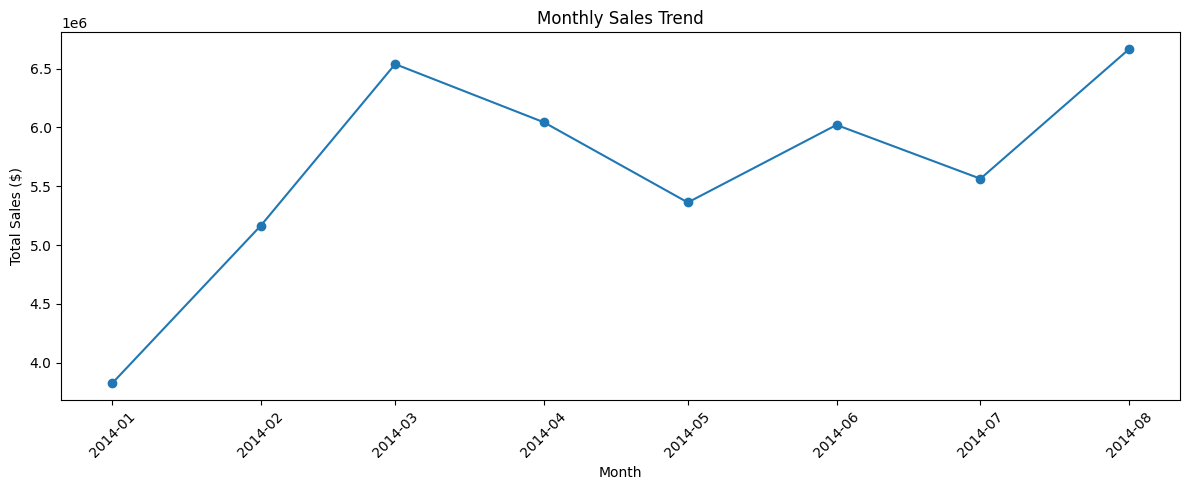

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Monthly Sales Trend
plt.figure(figsize=(12,5))
plt.plot(monthly['MonthID'], monthly['Total_Sales_Dollars'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Product Performance
Identifying top revenue-generating products.

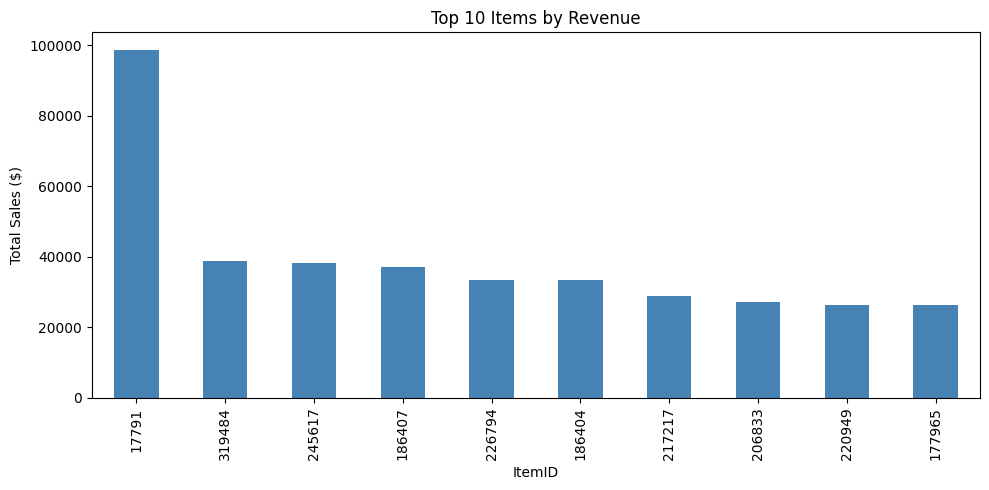

In [22]:
# 2. Top 10 Items by Revenue
plt.figure(figsize=(10,5))
top_items.plot(kind='bar', color='steelblue')
plt.title('Top 10 Items by Revenue')
plt.xlabel('ItemID')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

### 3.3 Location Performance
Ranking stores by total revenue and gross margin efficiency.

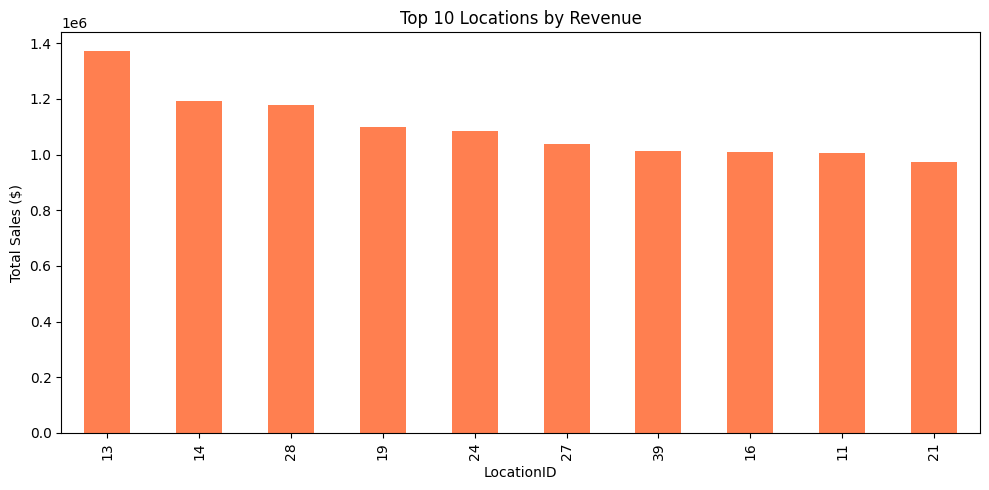

In [25]:
# 3. Top 10 Locations by Revenue
plt.figure(figsize=(10,5))
top_locations.plot(kind='bar', color='coral')
plt.title('Top 10 Locations by Revenue')
plt.xlabel('LocationID')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

### 3.4 Markdown Impact Analysis
Examining the relationship between markdown and regular sales channels.

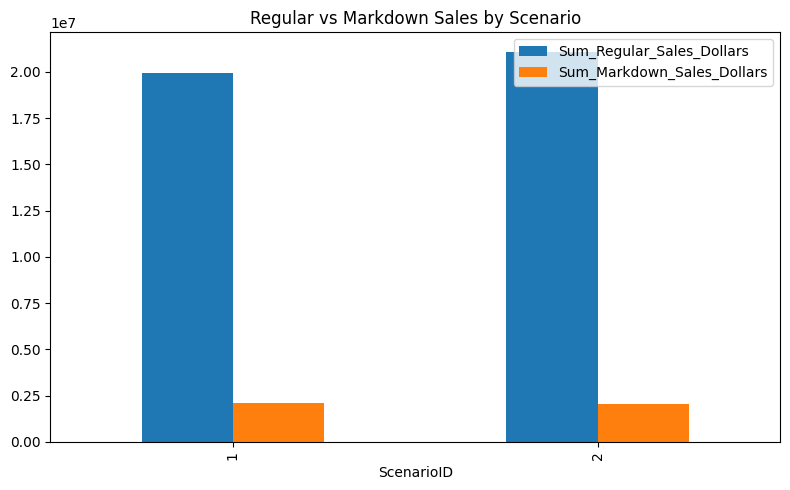

In [26]:
# 4. Regular vs Markdown Sales
scenario_sales = df.groupby('ScenarioID')[['Sum_Regular_Sales_Dollars','Sum_Markdown_Sales_Dollars']].sum()
scenario_sales.plot(kind='bar', figsize=(8,5))
plt.title('Regular vs Markdown Sales by Scenario')
plt.tight_layout()
plt.show()

## 4. Key Business Insights

1. **Seasonality:** Sales peak in August ($6.67M) and dip in January ($3.82M) — 
   promotions should be planned ahead of the January dip.
2. **Star Product:** Item 17791 generates $98,697 — 2.5x more than the next best item.
3. **Top Location:** Location 13 leads with $1.37M in revenue and strong margin.
4. **Margin Health:** Overall gross margin is 41.98% — consistent across all 100 locations.
5. **Markdown Efficiency:** Markdown sales are less than 10% of total revenue — 
   business is not discount-dependent.
6. **Scenario Parity:** Actual vs Plan variance is minimal ($22M vs $23.1M).

In [16]:
# Yearly sales comparison
yearly = df.groupby('Year')['Total_Sales_Dollars'].sum()
print(yearly)

Year
2014    45184553.69
Name: Total_Sales_Dollars, dtype: float64


In [17]:
# Gross margin % by location
loc_summary = df.groupby('LocationID').agg(
    Total_Sales=('Total_Sales_Dollars','sum'),
    Total_Margin=('Sum_GrossMarginAmount','sum')
).reset_index()
loc_summary['Margin_Pct'] = (loc_summary['Total_Margin'] / loc_summary['Total_Sales']) * 100
print(loc_summary.sort_values('Margin_Pct', ascending=False).head(10))

    LocationID  Total_Sales  Total_Margin  Margin_Pct
55         526    300005.86     140479.08   46.825445
41         507    339273.41     157737.33   46.492689
39         504    377798.57     174806.28   46.269704
48         518    292446.93     133538.48   45.662466
74         549    212133.19      95656.75   45.092779
70         545    185226.22      83386.19   45.018567
71         546    233176.26     104847.19   44.964779
63         537    255099.12     114423.79   44.854639
95         579    227014.07     101754.94   44.823187
50         520    280737.43     125788.61   44.806498


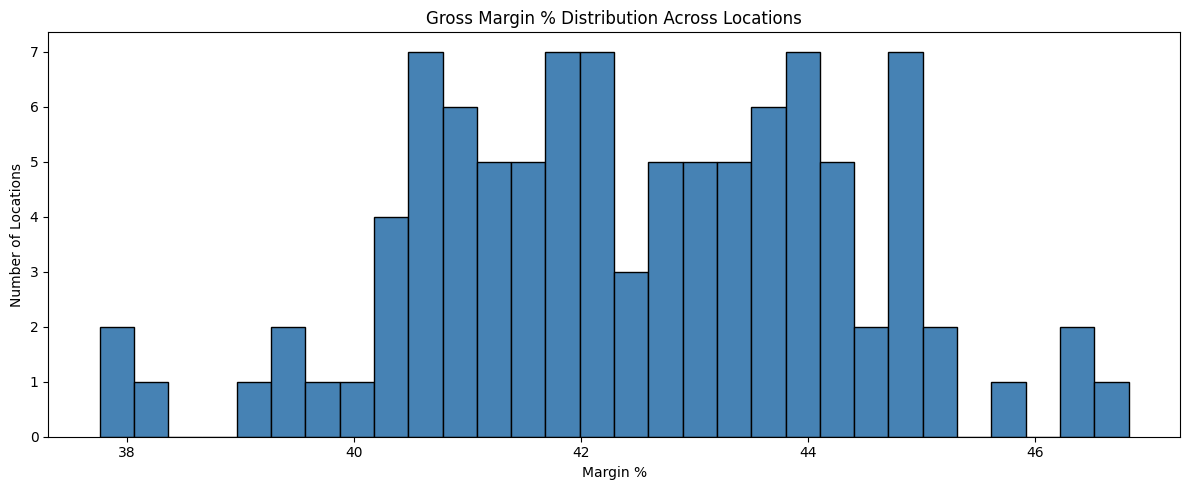

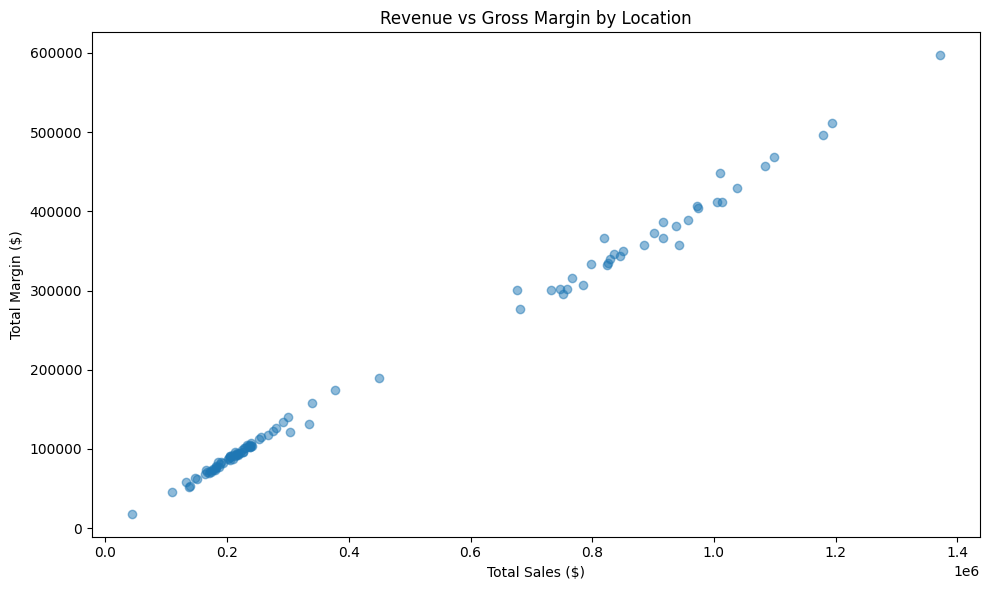

In [18]:
# Margin % distribution across all locations
plt.figure(figsize=(12,5))
plt.hist(loc_summary['Margin_Pct'], bins=30, color='steelblue', edgecolor='black')
plt.title('Gross Margin % Distribution Across Locations')
plt.xlabel('Margin %')
plt.ylabel('Number of Locations')
plt.tight_layout()
plt.show()

# Revenue vs Margin scatter
plt.figure(figsize=(10,6))
plt.scatter(loc_summary['Total_Sales'], loc_summary['Total_Margin'], alpha=0.5)
plt.title('Revenue vs Gross Margin by Location')
plt.xlabel('Total Sales ($)')
plt.ylabel('Total Margin ($)')
plt.tight_layout()
plt.show()

In [19]:
# Summary stats for your report
print("=== RETAIL SALES ANALYSIS SUMMARY ===")
print(f"Total Revenue (2014): ${df['Total_Sales_Dollars'].sum():,.2f}")
print(f"Total Gross Margin: ${df['Sum_GrossMarginAmount'].sum():,.2f}")
print(f"Overall Margin %: {(df['Sum_GrossMarginAmount'].sum() / df['Total_Sales_Dollars'].sum()) * 100:.2f}%")
print(f"Total Locations: {df['LocationID'].nunique()}")
print(f"Total Products: {df['ItemID'].nunique()}")
print(f"Best Month: {monthly.loc[monthly['Total_Sales_Dollars'].idxmax(), 'MonthID']}")
print(f"Worst Month: {monthly.loc[monthly['Total_Sales_Dollars'].idxmin(), 'MonthID']}")
print(f"Top Item: {top_items.idxmax()} (${top_items.max():,.2f})")
print(f"Top Location: {top_locations.idxmax()} (${top_locations.max():,.2f})")

=== RETAIL SALES ANALYSIS SUMMARY ===
Total Revenue (2014): $45,184,553.69
Total Gross Margin: $18,968,753.26
Overall Margin %: 41.98%
Total Locations: 100
Total Products: 105916
Best Month: 2014-08-01 00:00:00
Worst Month: 2014-01-01 00:00:00
Top Item: 17791 ($98,697.63)
Top Location: 13 ($1,370,946.11)
